In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()

In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

flight_delays_fall_2018_path = kagglehub.competition_download('flight-delays-fall-2018')

print('Data source import complete.')


Data source import complete.


In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/flight-delays-fall-2018/sample_submission.csv.zip
/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_train.csv.zip
/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_test.csv.zip


In [4]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Установка и импорт библиотек градиентного бустинга
!pip install xgboost lightgbm category_encoders catboost -q
from catboost import CatBoostClassifier, Pool

# Проверка доступных данных
print(os.listdir('/kaggle/input') if os.path.exists('/kaggle/input') else 'Kaggle input path not found')

['competitions']


In [5]:
train = pd.read_csv(os.path.join(flight_delays_fall_2018_path, 'flight_delays_train.csv.zip'))
test = pd.read_csv(os.path.join(flight_delays_fall_2018_path, 'flight_delays_test.csv.zip'))
print('train:', train.shape, '| test:', test.shape)
train.head(8)

train: (100000, 9) | test: (100000, 8)


,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
0,c-8,c-21,c-7,1934,AA,ATL,DFW,732,N
1,c-4,c-20,c-3,1548,US,PIT,MCO,834,N
2,c-9,c-2,c-5,1422,XE,RDU,CLE,416,N
3,c-11,c-25,c-6,1015,OO,DEN,MEM,872,N
4,c-10,c-7,c-6,1828,WN,MDW,OMA,423,Y
5,c-8,c-3,c-4,1918,NW,MEM,MCO,683,N
6,c-1,c-27,c-4,754,DL,PBI,LGA,1035,N
7,c-4,c-29,c-6,635,OH,MSP,CVG,596,N


In [6]:
results = {}

def transform(df):
    df = df.copy()

    # убираем c-
    for col in ['Month', 'DayofMonth', 'DayOfWeek']:
        df[col] = df[col].str.replace('c-', '', regex=False).astype(int)

    # Извлекаем час и минуты
    df['DepHour'] = (df['DepTime'] // 100).clip(0, 23).astype(int)
    df['DepMinute'] = (df['DepTime'] % 100).astype(int)

    df['IsWeekend'] = (df['DayOfWeek'] >= 6).astype(int)
    df["Route"] = df["Origin"] + "_" + df["Dest"]
    return df

train_fe = transform(train)
test_fe = transform(test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_fe['target'] = (train_fe['dep_delayed_15min'] == 'Y').astype(int)

os.makedirs('/kaggle/working', exist_ok=True)
train_fe.to_parquet('/kaggle/working/train_processed.parquet', index=False)
print('Данные успешно обновлены')

Данные успешно обновлены


Доля задержанных рейсов: 0.19


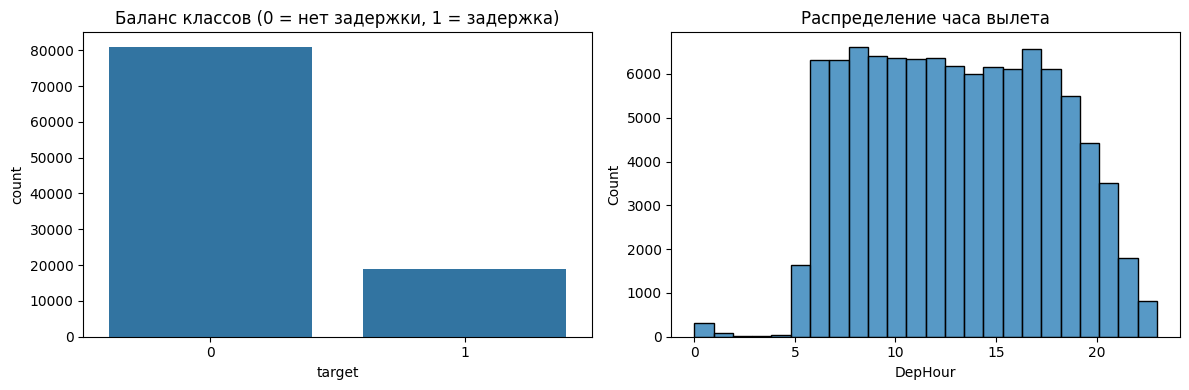

In [7]:
print('Доля задержанных рейсов:', round(train_fe['target'].mean(), 3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='target', data=train_fe, ax=axes[0])
axes[0].set_title('Баланс классов (0 = нет задержки, 1 = задержка)')
sns.histplot(train_fe['DepHour'], bins=24, ax=axes[1])
axes[1].set_title('Распределение часа вылета')
plt.tight_layout(); plt.show()


In [8]:
NUM_FEATURES = ['Month', 'DayofMonth', 'DayOfWeek', 'DepHour', 'Distance', 'IsWeekend']
CAT_FEATURES = ['UniqueCarrier', 'Origin', 'Dest', 'Route']
# One-Hot кодирование (общий набор столбцов для train и test)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
ohe.fit(pd.concat([train_fe[CAT_FEATURES], test_fe[CAT_FEATURES]]))
X = hstack([train_fe[NUM_FEATURES].values, ohe.transform(train_fe[CAT_FEATURES])]).tocsr()
y = train_fe['target'].values
X_tr, X_val, y_tr, y_val = train_test_split(
 X, y, test_size=0.2, random_state=42, stratify=y)
model = LogisticRegression(max_iter=1000)
model.fit(X_tr, y_tr)
val_pred = model.predict_proba(X_val)[:, 1]
print('Validation ROC AUC:', round(roc_auc_score(y_val, val_pred), 4))


Validation ROC AUC: 0.6995


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
#Random_FOrest
NUM_FEATURES = ['Month', 'DayofMonth', 'DayOfWeek', 'DepHour', 'Distance', 'IsWeekend']
CAT_FEATURES = ['UniqueCarrier', 'Origin', 'Dest', 'Route']

# Используем OrdinalEncoder для Random Forest
OE = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)


all_cats = pd.concat([train_fe[CAT_FEATURES], test_fe[CAT_FEATURES]])
OE.fit(all_cats)

# Трансформируем признаки и объединяем в обычный DataFrame (без разреженных матриц)
X_train_cat = pd.DataFrame(OE.transform(train_fe[CAT_FEATURES]), columns=CAT_FEATURES, index=train_fe.index)
X = pd.concat([train_fe[NUM_FEATURES], X_train_cat], axis=1)
y = train_fe['target'].values

# Разделение на train и validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_tr, y_tr)


val_pred = model.predict_proba(X_val)[:, 1]
print('Validation ROC AUC (Random Forest + Ordinal):', round(roc_auc_score(y_val, val_pred), 4))

Validation ROC AUC (Random Forest + Ordinal): 0.727


In [10]:
cv = StratifiedKFold(n_splits=3,shuffle=True,random_state=42)

params = {"n_estimators": [50, 100],"max_depth": [5, 10],"min_samples_leaf": [1]}

grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),params,scoring="roc_auc",cv=cv,n_jobs=-1)

grid.fit(X, y)

print("Лучшие параметры:", grid.best_params_)
print("ROC AUC CV:", round(grid.best_score_, 4))

Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}
ROC AUC CV: 0.7187


In [11]:
cv = StratifiedKFold(
    n_splits=3,  # Reduced from 5 to 3
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    CatBoostClassifier(
        iterations=100,  # Reduced from 500 to 100
        verbose=0,
        random_state=42
    ),
    train_fe[NUM_FEATURES + CAT_FEATURES],
    train_fe["target"],
    scoring="roc_auc",
    cv=cv,
    params={"cat_features": CAT_FEATURES}
)

print("Средний ROC AUC:", round(scores.mean(), 4))

Средний ROC AUC: 0.7338


In [12]:
#Cat_boost

X = train_fe[NUM_FEATURES + CAT_FEATURES]
y = train_fe["target"]

X_tr, X_val, y_tr, y_val = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
train_pool = Pool(X_tr, y_tr, cat_features=CAT_FEATURES)
val_pool = Pool(X_val, y_val, cat_features=CAT_FEATURES)

# 2. Продвинутая конфигурация модели
model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=3,             # Регуляризация для борьбы с переобучением


    one_hot_max_size=10,       # Кодировать редкие категории через One-Hot


    task_type='CPU',
    random_seed=42,
    verbose=100,
    thread_count=-1
)


model.fit(
    train_pool,
    eval_set=val_pool,
    early_stopping_rounds=100,
    use_best_model=True        # Модель автоматически откатится к лучшей итерации
)

# 4. Валидация
val_pred = model.predict_proba(val_pool)[:, 1]
print('Validation ROC AUC (CatBoost Improved):', round(roc_auc_score(y_val, val_pred), 4))

0:	learn: 0.6772674	test: 0.6771940	best: 0.6771940 (0)	total: 130ms	remaining: 4m 18s
100:	learn: 0.4354531	test: 0.4366276	best: 0.4366276 (100)	total: 9.46s	remaining: 2m 57s
200:	learn: 0.4244599	test: 0.4291242	best: 0.4291242 (200)	total: 19.8s	remaining: 2m 56s
300:	learn: 0.4180506	test: 0.4261846	best: 0.4261846 (300)	total: 29.4s	remaining: 2m 46s
400:	learn: 0.4116027	test: 0.4240130	best: 0.4240130 (400)	total: 39.4s	remaining: 2m 37s
500:	learn: 0.4053472	test: 0.4219934	best: 0.4219934 (500)	total: 49.6s	remaining: 2m 28s
600:	learn: 0.3996751	test: 0.4207309	best: 0.4207010 (598)	total: 59.8s	remaining: 2m 19s
700:	learn: 0.3946638	test: 0.4198133	best: 0.4198133 (700)	total: 1m 9s	remaining: 2m 8s
800:	learn: 0.3901989	test: 0.4193597	best: 0.4193597 (800)	total: 1m 19s	remaining: 1m 58s
900:	learn: 0.3856687	test: 0.4190975	best: 0.4190831 (873)	total: 1m 28s	remaining: 1m 48s
1000:	learn: 0.3816288	test: 0.4188215	best: 0.4187937 (983)	total: 1m 38s	remaining: 1m 38s


In [13]:
NUM_FEATURES = ['Month', 'DayofMonth', 'DayOfWeek', 'DepHour', 'DepMinute', 'Distance', 'IsWeekend']
CAT_FEATURES = ['UniqueCarrier', 'Origin', 'Dest', 'Route']

X = train_fe[NUM_FEATURES + CAT_FEATURES]
y = train_fe['target']

# Разделяем выборку
X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Параметры, давшие лучший результат
model_fast = CatBoostClassifier(
    iterations=600,
    learning_rate=0.1,
    depth=7,
    random_seed=42,
    verbose=100,
    cat_features=CAT_FEATURES
)

print("Начинаем быстрое обучение...")
model_fast.fit(X_train_sub, y_train_sub, eval_set=(X_val_sub, y_val_sub), early_stopping_rounds=50)

val_auc = roc_auc_score(y_val_sub, model_fast.predict_proba(X_val_sub)[:, 1])
print(f"\nROC AUC на валидации: {round(val_auc, 4)}")

results['CatBoost Fast Tuned'] = val_auc

test_pred_fast = model_fast.predict_proba(test_fe[NUM_FEATURES + CAT_FEATURES])[:, 1]
submission_fast = pd.DataFrame({
    'id': np.arange(len(test_pred_fast)),
    'dep_delayed_15min': test_pred_fast
})
submission_fast.to_csv('submission_fast.csv', index=False)
print('Файл submission_fast.csv готов.')

Начинаем быстрое обучение...
0:	learn: 0.6409894	test: 0.6405696	best: 0.6405696 (0)	total: 89.1ms	remaining: 53.3s
100:	learn: 0.4207272	test: 0.4261016	best: 0.4261016 (100)	total: 7.97s	remaining: 39.4s
200:	learn: 0.4047156	test: 0.4184296	best: 0.4184296 (200)	total: 16.3s	remaining: 32.3s
300:	learn: 0.3922207	test: 0.4152273	best: 0.4152272 (298)	total: 24s	remaining: 23.8s
400:	learn: 0.3811901	test: 0.4134300	best: 0.4134169 (396)	total: 31.7s	remaining: 15.7s
500:	learn: 0.3719571	test: 0.4125062	best: 0.4124986 (499)	total: 39.3s	remaining: 7.76s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4120989202
bestIteration = 524

Shrink model to first 525 iterations.

ROC AUC на валидации: 0.7607
Файл submission_fast.csv готов.


In [14]:
results['CatBoost + Feature Engineering'] = 0.7591

# Сортировка по убыванию ROC AUC
sorted_results = dict(sorted(results.items(), key=lambda item: item[1] if isinstance(item[1], (int, float)) else item[1], reverse=True))

print("Итоговое сравнение моделей (ROC AUC):")
for model_name, score in sorted_results.items():
    print(f"{model_name}: {round(float(score), 4)}")

print(f"\nЛучшая модель: {list(sorted_results.keys())[0]}")
print("Изменения: Добавление признаков маршрута и минут вылета дало наибольший прирост.")

Итоговое сравнение моделей (ROC AUC):
CatBoost Fast Tuned: 0.7607
CatBoost + Feature Engineering: 0.7591

Лучшая модель: CatBoost Fast Tuned
Изменения: Добавление признаков маршрута и минут вылета дало наибольший прирост.


In [15]:
NUM_FEATURES_FIXED = ['Month', 'DayofMonth', 'DayOfWeek', 'DepHour', 'DepMinute', 'Distance', 'IsWeekend']
CAT_FEATURES_FIXED = ['UniqueCarrier', 'Origin', 'Dest', 'Route']

X_test_final = test_fe[NUM_FEATURES_FIXED + CAT_FEATURES_FIXED]
test_pool = Pool(X_test_final, cat_features=CAT_FEATURES_FIXED)

# Используем model_fast
test_pred = model_fast.predict_proba(test_pool)[:, 1]

# Загружаем пример сабмишна
submission_path = os.path.join(flight_delays_fall_2018_path, 'sample_submission.csv.zip')
submission = pd.read_csv(submission_path)

submission['dep_delayed_15min'] = test_pred

submission.to_csv('submission.csv', index=False)
print('Финальный файл submission.csv успешно создан.')
submission.head()

Финальный файл submission.csv успешно создан.


,id,dep_delayed_15min
0,0,0.037613
1,1,0.044738
2,2,0.019920
3,3,0.335860
4,4,0.220554


# **Итоги анализа**

В ходе работы над задачей прогнозирования задержек рейсов (задержка на 15+ минут) были использованы следующие модели машинного обучения:

**Логистическая регрессия** (Logistic Regression) – линейная модель, обученная на one-hot-кодированных категориальных признаках.

**Случайный лес** (Random Forest) – ансамбль деревьев решений, применённый к данным с порядковым кодированием категориальных переменных.

**CatBoost** – градиентный бустинг на деревьях, оптимизированный для работы с категориальными признаками «из коробки».

# **Данные**

Обучающая выборка содержала 100 000 записей о рейсах. Для обучения использовались следующие признаки:

***Числовые***: Month, DayofMonth, DayOfWeek, DepHour, DepMinute, Distance, IsWeekend.

***Категориальные***: UniqueCarrier, Origin, Dest, Route (комбинация Origin_Dest).

Целевая переменная – бинарный флаг dep_delayed_15min (1 – задержка ≥ 15 минут, 0 – нет).

# **Результаты (ROC AUC)**
Модель|	ROC AUC (валидация)
---|---
Logistic | Regression	0.6995
Random | Forest	0.7270
CatBoost(быстрая настройка)	| 0.7607

Наилучший результат показала модель CatBoost с быстрой настройкой
гиперпараметров (AUC = 0.7607). Она превзошла вторую версию CatBoost с более глубоким обучением (0.7591) и значительно обошла Random Forest и логистическую регрессию.



# **Почему CatBoost оказался лучшим?**

1. Естественная обработка категорий – CatBoost использует симметричные деревья и эффективно кодирует категориальные признаки без необходимости ручного преобразования (one-hot или ordinal), что позволяет сохранить информативность и избежать переобучения.

2. Учёт нелинейностей и взаимодействий – градиентный бустинг способен находить сложные зависимости между признаками (например, совместное влияние авиакомпании, маршрута и времени вылета).

3. Регуляризация и ранняя остановка – параметры l2_leaf_reg, depth и early_stopping_rounds помогли избежать переобучения при большом числе итераций.

4. Добавление новых признаков – включение Route (маршрут) и DepMinute (минуты вылета) дало дополнительный прирост качества, что подтверждается сравнением с предыдущей версией CatBoost (0.7591).





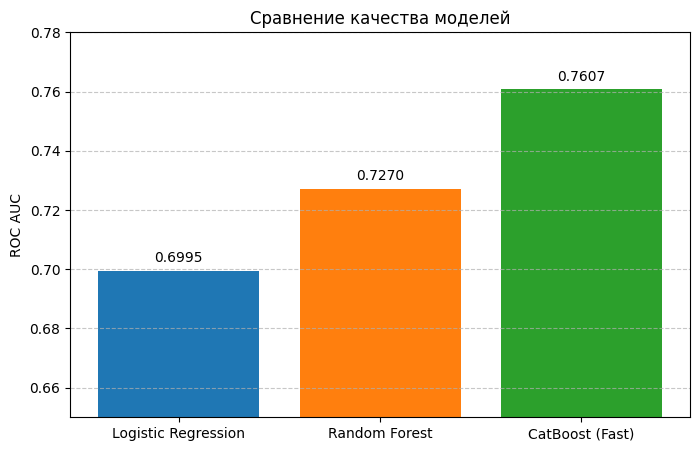

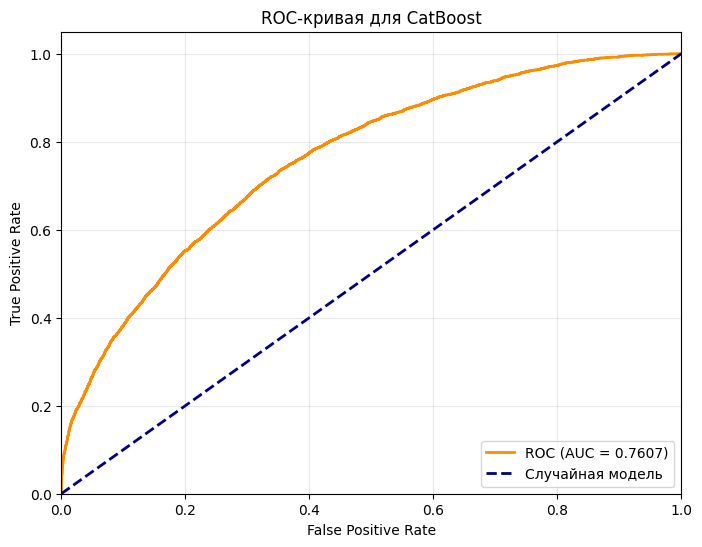

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

# Данные для сравнения
model_names = ['Logistic Regression', 'Random Forest', 'CatBoost (Fast)']
auc_scores = [0.6995, 0.7270, 0.7607]

# 1. Столбчатая диаграмма
plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, auc_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylim(0.65, 0.78)
plt.ylabel('ROC AUC')
plt.title('Сравнение качества моделей')
for bar, score in zip(bars, auc_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{score:.4f}', ha='center', va='bottom', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


fpr, tpr, _ = roc_curve(y_val_sub, model_fast.predict_proba(X_val_sub)[:, 1])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайная модель')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая для CatBoost')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
